# K-Nearest Neighbors Classifier

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

# Data Loading & Inspection 

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (569, 31)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

In [4]:
print("\nClass Distribution:")
print(df['target'].value_counts())

print("\nMissing Values:", df.isnull().sum().sum())


Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing Values: 0


## Data Visualization

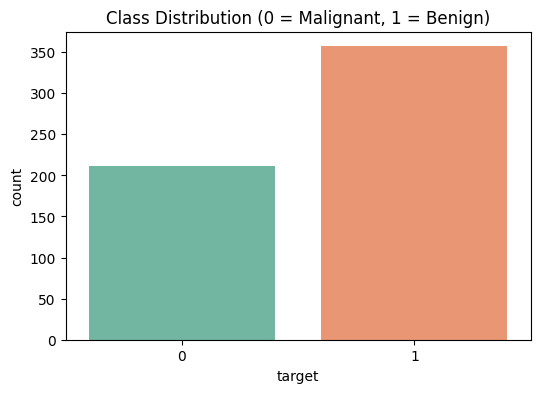

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', hue='target', data=df, palette='Set2', legend=False)
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.show()

In [3]:
X_all = df.drop('target', axis=1)
y     = df['target']

print(f"Total features before selection: {X_all.shape[1]}")

Total features before selection: 30


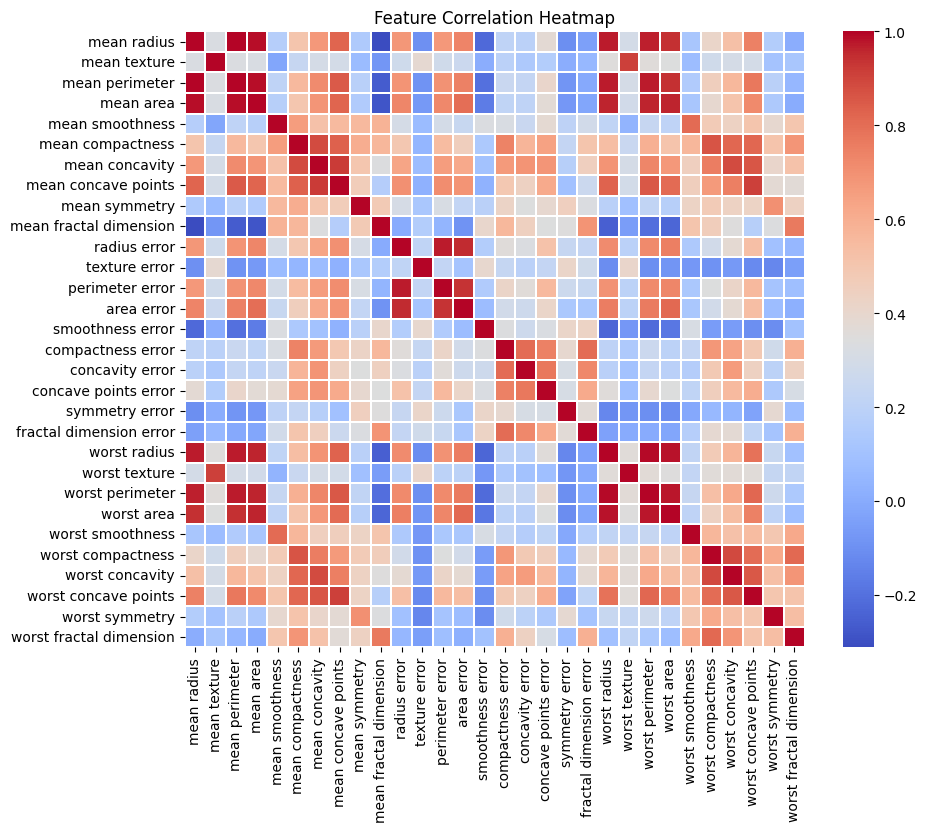

In [4]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.drop('target', axis=1).corr(),
    cmap='coolwarm',
    linewidths=0.3,
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

### PCA Visualization

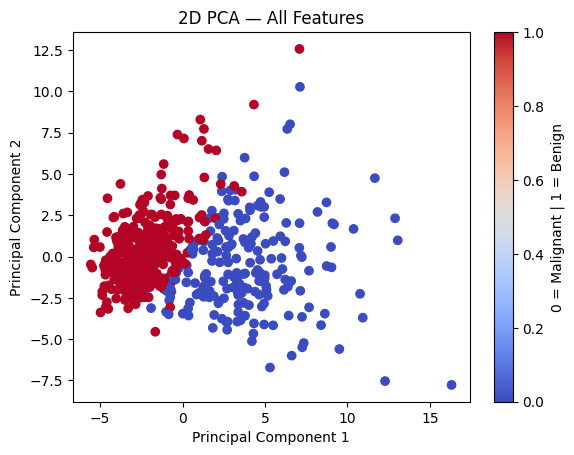

In [9]:
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_all)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.title('2D PCA — All Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='0 = Malignant | 1 = Benign')
plt.show()

In [13]:
import pickle

with open("pca.pkl", "wb") as file:
    pickle.dump(pca, file)

### Preprocessing

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, random_state=1, stratify=y
)

print(f"Train size: {X_train_raw.shape[0]} samples")
print(f"Test  size: {X_test_raw.shape[0]} samples")

Train size: 398 samples
Test  size: 171 samples


Step 1 — Remove Highly Correlated Features

In [6]:
corr_matrix = X_train_raw.corr(numeric_only=True).abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_with_target = X_train_raw.corrwith(y_train).abs()

to_drop = set()
for col in upper.columns:
    highly_correlated = upper.index[upper[col] > 0.9].tolist()
    for corr_feat in highly_correlated:
        if corr_with_target[col] < corr_with_target[corr_feat]:
            to_drop.add(col)
        else:
            to_drop.add(corr_feat)

to_drop = list(to_drop)
X_train_step1 = X_train_raw.drop(columns=to_drop)
X_test_step1  = X_test_raw.drop(columns=to_drop)

print(f"Step 1: {len(to_drop)} features removed, {X_train_step1.shape[1]} remained")
print(f"Dropped: {to_drop}")

Step 1: 10 features removed, 20 remained
Dropped: ['worst radius', 'mean texture', 'mean area', 'mean concave points', 'mean radius', 'worst area', 'perimeter error', 'mean concavity', 'area error', 'mean perimeter']


Step 2 — Select Top 10 Features by Correlation with Target

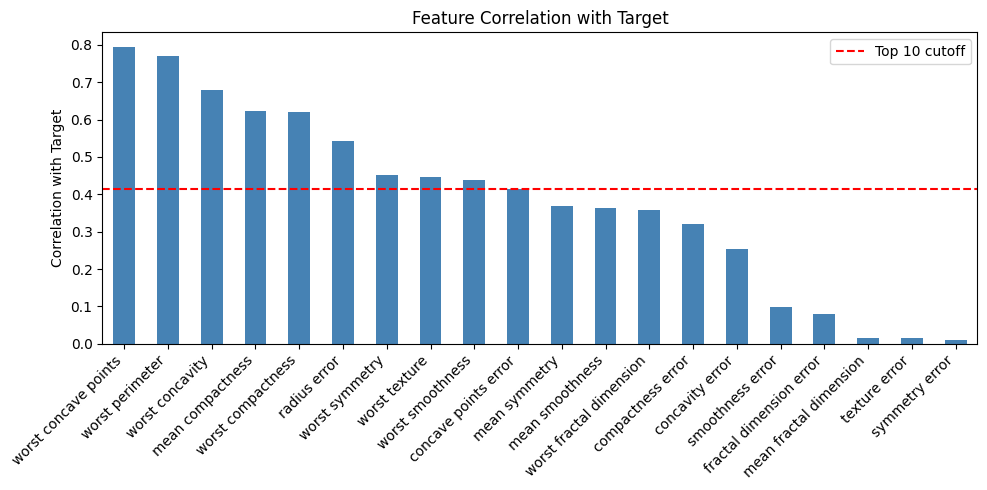


Step 2 — Top 10 Features:
   1. worst concave points (corr=0.794)
   2. worst perimeter (corr=0.770)
   3. worst concavity (corr=0.680)
   4. mean compactness (corr=0.623)
   5. worst compactness (corr=0.620)
   6. radius error (corr=0.543)
   7. worst symmetry (corr=0.451)
   8. worst texture (corr=0.446)
   9. worst smoothness (corr=0.438)
  10. concave points error (corr=0.414)


In [7]:
target_corr = X_train_step1.corrwith(y_train).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
target_corr.plot(kind='bar', color='steelblue')
plt.axhline(y=target_corr.iloc[9], color='red', linestyle='--', label='Top 10 cutoff')
plt.title('Feature Correlation with Target')
plt.ylabel('Correlation with Target')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

top_features = target_corr.head(10).index.tolist()
print(f"\nStep 2 — Top 10 Features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f} (corr={target_corr[f]:.3f})")

X_train_sel = X_train_step1[top_features]
X_test_sel  = X_test_step1[top_features]

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_sel)   
X_test  = scaler.transform(X_test_sel)         

print("Train shape:", X_train.shape)
print("Test  shape:", X_test.shape)

Train shape: (398, 10)
Test  shape: (171, 10)


In [38]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Build KNN model from scratch 

In [9]:
import numpy as np
from collections import Counter

class KNN_From_Scratch:
    def __init__(self, k=4):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

        k_indices = np.argsort(distances)[:self.k]

        k_nearest_labels = self.y_train[k_indices]

        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

Determine the best K value

In [10]:
# sklearn
error_rate = []
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

best_k = error_rate.index(min(error_rate)) + 1
print(f"Best K value (Sklearn): {best_k}")

# From Scratch
error_rate = []
for i in range(1,20):
    knn = KNN_From_Scratch(k=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
best_k = error_rate.index(min(error_rate)) +1
print(f"Best k value (From scratch): {best_k}")

Best K value (Sklearn): 4
Best k value (From scratch): 4


In [11]:
import json

with open("best_k.json", "w") as f:
    json.dump({"best_k": best_k, "error_rate": error_rate}, f)

In [41]:
k_value = 4
from scipy.spatial.distance import cdist
# Model 1: Scratch
knn_scratch = KNN_From_Scratch(k=k_value)
knn_scratch.fit(X_train, y_train)
y_pred_scratch = knn_scratch.predict(X_test)
acc_scratch = accuracy_score(y_test, y_pred_scratch)

In [42]:
# Model 2: Scikit-Learn
knn_sklearn = KNeighborsClassifier(n_neighbors=k_value)
knn_sklearn.fit(X_train, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Accuracy (From Scratch): {acc_scratch:.4f}")
print(f"Accuracy (Scikit-Learn): {acc_sklearn:.4f}")

Accuracy (From Scratch): 0.9591
Accuracy (Scikit-Learn): 0.9532


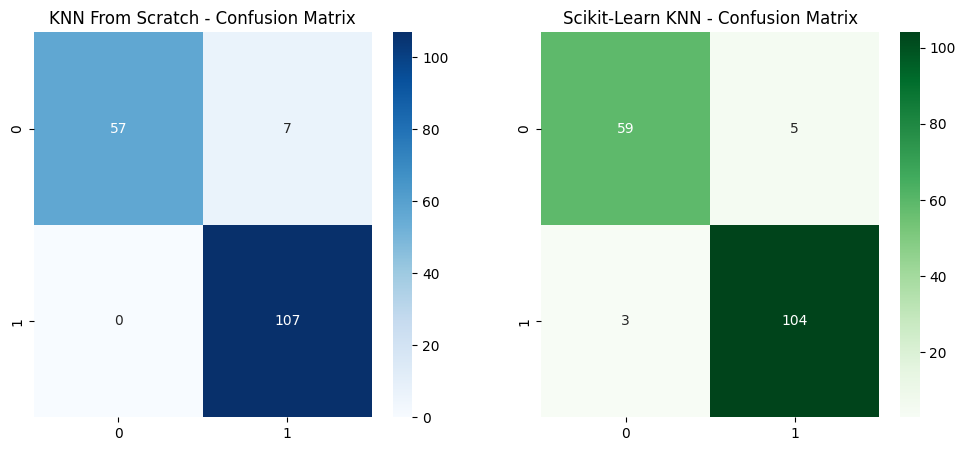

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('KNN From Scratch - Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, y_pred_sklearn), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Scikit-Learn KNN - Confusion Matrix')
plt.show()

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_scratch),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('KNN From Scratch - Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, y_pred_sklearn),
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Scikit-Learn KNN - Confusion Matrix')

plt.tight_layout()

# 💾 Save image
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches='tight')

plt.close()

In [45]:
print("\nClassification Report Scratch:\n", classification_report(y_test, y_pred_scratch))
print("\nClassification Report Scikit-Learn:\n", classification_report(y_test, y_pred_sklearn))


Classification Report Scratch:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


Classification Report Scikit-Learn:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



In [46]:
from sklearn.metrics import classification_report

report_scratch = classification_report(y_test, y_pred_scratch)
report_sklearn = classification_report(y_test, y_pred_sklearn)

with open("classification_report.txt", "w") as f:
    f.write("=== KNN From Scratch ===\n")
    f.write(report_scratch)
    f.write("\n\n=== Scikit-Learn KNN ===\n")
    f.write(report_sklearn)

In [26]:
import joblib
joblib.dump(knn_scratch, 'knn_scratch.pkl')
joblib.dump(knn_sklearn, 'knn_sklearn.pkl')

['knn_sklearn.pkl']

In [47]:
joblib.dump(top_features, "features.pkl")

print("✅ File Saved Successfully")

✅ File Saved Successfully


In [ ]:
import json
from sklearn.metrics import classification_report

# SKLEARN MODEL REPORT
report_sklearn = classification_report(y_test, y_pred_sklearn, output_dict=True)

with open("report_sklearn.json", "w") as f:
    json.dump(report_sklearn, f)

# SCRATCH MODEL REPORT
report_scratch = classification_report(y_test, y_pred_scratch, output_dict=True)

with open("report_scratch.json", "w") as f:
    json.dump(report_scratch, f)

print("Reports saved successfully ✔")

Reports saved successfully ✔
